<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/Experiment_04_Deep_Learning_Lab_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training with 4 hidden neurons...


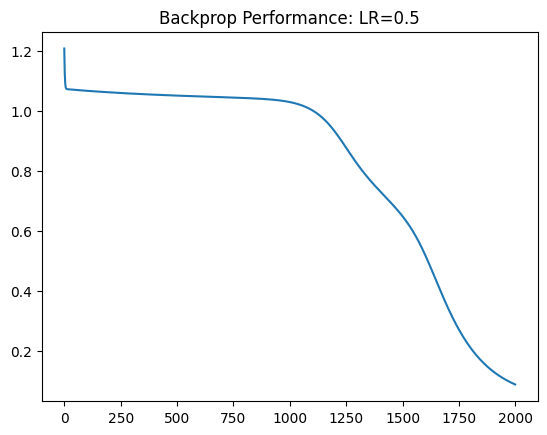

In [2]:
# hidden_neurons = 4
# learning_rate = 0.5
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Hidden Layer
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    # Output Layer
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1: # Hidden Layer Error Calculation
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else: # Output Layer Error Calculation
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])

        # Calculate Delta (The "Instruction" for the weight)
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. WEIGHT UPDATE ---
def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
# Dataset: XOR [Input1, Input2, Expected]
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]

# Modify these lines for variations
hidden_neurons = 4   # Change to 0 for linear test
learning_rate = 0.5  # Change to 0.01 for slow test

network = initialize_network(2, hidden_neurons, 1)
print(f"Training with {hidden_neurons} hidden neurons...")
errors = train_network(network, dataset, learning_rate, 2000)

plt.plot(errors)
plt.title(f'Backprop Performance: LR={learning_rate}')
plt.show()

Training with 4 hidden neurons...


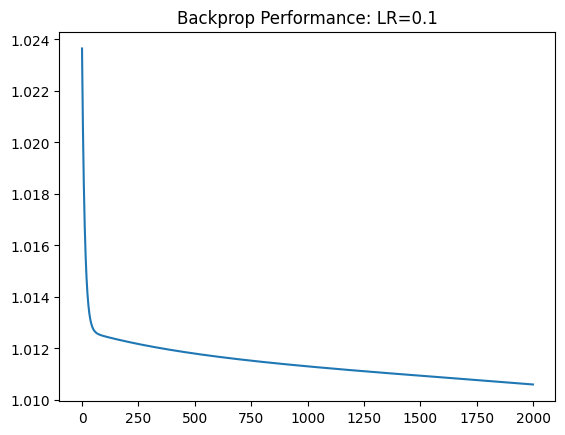

In [3]:
# hidden_neurons = 4
# learning_rate = 0.01
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Hidden Layer
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    # Output Layer
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1: # Hidden Layer Error Calculation
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else: # Output Layer Error Calculation
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])

        # Calculate Delta (The "Instruction" for the weight)
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. WEIGHT UPDATE ---
def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
# Dataset: XOR [Input1, Input2, Expected]
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]

# Modify these lines for variations
hidden_neurons = 4   # Change to 0 for linear test
learning_rate = 0.1  # Change to 0.01 for slow test

network = initialize_network(2, hidden_neurons, 1)
print(f"Training with {hidden_neurons} hidden neurons...")
errors = train_network(network, dataset, learning_rate, 2000)

plt.plot(errors)
plt.title(f'Backprop Performance: LR={learning_rate}')
plt.show()

Training with 0 hidden neurons...


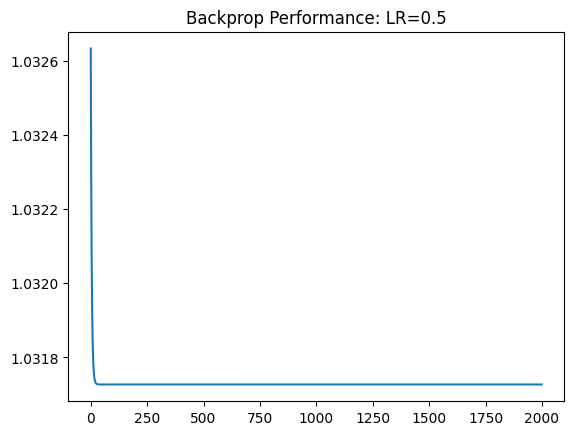

In [4]:
# hidden_neurons = 0
# learning_rate = 0.05
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Hidden Layer
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    # Output Layer
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1: # Hidden Layer Error Calculation
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else: # Output Layer Error Calculation
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])

        # Calculate Delta (The "Instruction" for the weight)
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. WEIGHT UPDATE ---
def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
# Dataset: XOR [Input1, Input2, Expected]
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]

# Modify these lines for variations
hidden_neurons = 0   # Change to 0 for linear test
learning_rate = 0.5  # Change to 0.01 for slow test

network = initialize_network(2, hidden_neurons, 1)
print(f"Training with {hidden_neurons} hidden neurons...")
errors = train_network(network, dataset, learning_rate, 2000)

plt.plot(errors)
plt.title(f'Backprop Performance: LR={learning_rate}')
plt.show()